# Email Subject Generator — Encoder-Decoder LSTM

**Conditional text generation using a seq2seq architecture.**

This notebook walks through the full pipeline: data loading, preprocessing, model architecture, training, and inference.

The architecture is an encoder-decoder (seq2seq) LSTM — the same architectural class as early neural machine translation systems ([Sutskever et al., 2014](https://arxiv.org/abs/1409.3215)). The task: given an email body, generate a professional subject line. This is *conditional text generation* — generating text conditioned on an input sequence.

**Portfolio context:** The IMDb sentiment and stock trend projects demonstrate *discriminative* LSTMs — classifying sequences into fixed categories. This project demonstrates a *generative* LSTM — generating novel sequences from an encoded input. A different use of the same architecture.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import json
from pathlib import Path

import tensorflow as tf
print(f"TensorFlow {tf.__version__}")

from config import (
    MAX_BODY_LEN, MAX_SUBJECT_LEN, MIN_SUBJECT_LEN,
    START_TOKEN, END_TOKEN, LATENT_DIM, EMBEDDING_DIM,
    EPOCHS, BATCH_SIZE, VALIDATION_SPLIT, LEARNING_RATE,
    TEMPERATURE, NUM_SUGGESTIONS, MODEL_DIR, PLOTS_DIR
)
print("Config loaded.")

TensorFlow 2.16.2
Config loaded.


## The Seq2Seq Architecture

```
Email body characters → [Encoder LSTM] → context vector [h, c]
                                                    ↓
                         [Decoder LSTM] ← [h, c] + START_TOKEN
                              ↓
                    character by character →  Subject line
```

**Encoder:** reads the email body character by character. The final hidden state `[h, c]` — called the *context vector* — encodes the entire input into a fixed-size representation. This is what passes meaning from encoder to decoder.

**Decoder:** initialised with the context vector. At each step it predicts the next character, given the context and its own previous output. Generation stops when `>` (end token) is produced or max length is reached.

**Why character-level?** Avoids vocabulary limitations — no out-of-vocabulary tokens, can generate any casing or punctuation. Trade-off: longer sequences, slower inference. Acceptable for 60-character subject lines.

## Teacher Forcing and Exposure Bias

**Teacher forcing** is a training technique where the decoder receives the *correct* previous character at each step, rather than its own previous prediction.

Without teacher forcing, early decoder errors cascade — if the model predicts the wrong character at step 2, step 3 sees a corrupted input, and the errors compound. This makes training unstable and slow.

With teacher forcing, each training step is independent — the model always gets a clean input — making training fast and stable.

**The trade-off:** at inference time, no ground truth exists. The model sees its own (imperfect) previous outputs — a distribution shift from training. This is called *exposure bias*. For short outputs like subject lines (< 60 characters), exposure bias is manageable and teacher forcing's training benefits outweigh it.

**Why two separate models?** The training model uses teacher forcing (fixed-length inputs, known previous characters). The inference model runs autoregressively (one character at a time, feeding its own output back). Keras requires two separate graph structures to support both modes.

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/6.26M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/896k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/794k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/14436 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1960 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1906 [00:00<?, ? examples/s]

Total pairs loaded: 17437
Body length  — min: 23, max: 200, mean: 195.2
Subject length — min: 5, max: 62, mean: 26.3
Body vocabulary size: 69
Subject vocabulary size: 66

--- Sample pairs ---
Body:    greg/phillip,  attached is the grande communications service agreement.
the busi...
Subject: <service agreement>

Body:    phillip & keith  attached is the first draw request, i will need some of these f...
Subject: <bishops corner>

Body:    your internet banking accounts are now setup again for accessing.
the login id i...
Subject: <internet banking>

Body:    to our ibs customers that are still hanging in there:  we understand your contin...
Subject: <internet banking>

Body:    phillip good morning!
i hope you had a wonderful thanksgiving with your family a...
Subject: <smes for expert stories>



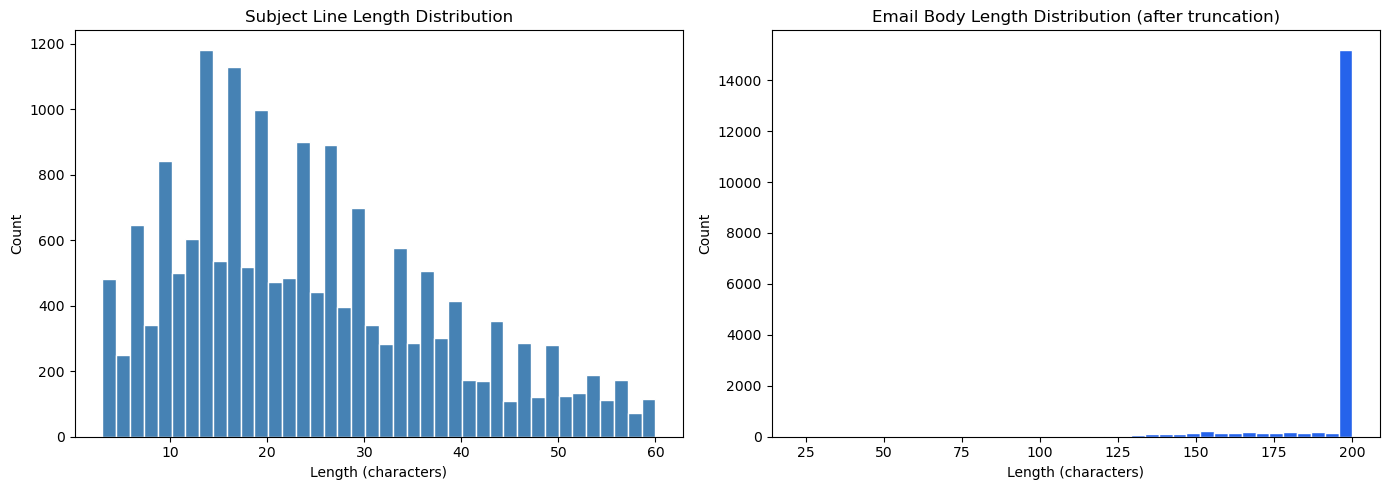

In [2]:
from preprocess import load_and_clean_data

bodies, subjects = load_and_clean_data()

print("\n--- Sample pairs ---")
for body, subject in zip(bodies[:5], subjects[:5]):
    print(f"Body:    {body[:80]}...")
    print(f"Subject: {subject}")
    print()

# Charts 02 and 03 inline
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

subject_lengths = [len(s) - 2 for s in subjects]  # exclude start/end tokens
ax1.hist(subject_lengths, bins=40, color='steelblue', edgecolor='white')
ax1.set_title('Subject Line Length Distribution')
ax1.set_xlabel('Length (characters)')
ax1.set_ylabel('Count')

body_lengths = [len(b) for b in bodies]
ax2.hist(body_lengths, bins=40, color='#2563EB', edgecolor='white')
ax2.set_title('Email Body Length Distribution (after truncation)')
ax2.set_xlabel('Length (characters)')
ax2.set_ylabel('Count')

plt.tight_layout()
plt.show()

In [3]:
from preprocess import build_vocabulary, save_vocab

all_texts = bodies + subjects
char_to_idx, idx_to_char = build_vocabulary(all_texts)
vocab_size = len(char_to_idx)

print(f"Vocabulary size: {vocab_size}")
print(f"\nSample char → index mappings:")
sample_chars = [' ', 'a', 'e', 'i', 'o', 'u', START_TOKEN, END_TOKEN, '.', ',']
for c in sample_chars:
    idx = char_to_idx.get(c, 'NOT FOUND')
    print(f"  {repr(c):6s} → {idx}")

save_vocab(char_to_idx, idx_to_char)

Vocabulary size: 71

Sample char → index mappings:
  ' '    → 4
  'a'    → 42
  'e'    → 46
  'i'    → 50
  'o'    → 56
  'u'    → 62
  '<'    → 32
  '>'    → 34
  '.'    → 18
  ','    → 16
Vocabulary saved to models/vocab.json


In [4]:
from model import build_encoder, build_decoder, build_training_model, build_inference_models

encoder_model, encoder_inputs, encoder_states = build_encoder(vocab_size)
decoder_outputs, _, decoder_inputs, decoder_embedding, decoder_lstm, decoder_dense = build_decoder(vocab_size, encoder_states)
training_model = build_training_model(encoder_inputs, decoder_inputs, decoder_outputs)

print("=== Encoder ===")
encoder_model.summary()
print("\n=== Training model ===")
training_model.summary()

total_params = training_model.count_params()
print(f"\nTotal trainable parameters: {total_params:,}")

=== Encoder ===


Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_inputs      │ (None, 200)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_embedding   │ (None, 200, 64)   │      4,544 │ encoder_inputs[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 200)       │          0 │ encoder_inputs[0… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_lstm (LSTM) │ [(None, 256),     │    328,704 │ encoder_embeddin… │
│                     │ (None, 256),      │            │ not_equal[0][0]   │
│                     │ (None, 256)]      │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 333,248 (1.27 MB)

 Trainable params: 333,248 (1.27 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_inputs      │ (None, 200)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_inputs      │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_embedding   │ (None, 200, 64)   │      4,544 │ encoder_inputs[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 200)       │          0 │ encoder_inputs[0… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_embedding   │ (None, None, 64)  │      4,544 │ decoder_inputs[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_lstm (LSTM) │ [(None, 256),     │    328,704 │ encoder_embeddin… │
│                     │ (None, 256),      │            │ not_equal[0][0]   │
│                     │ (None, 256)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_lstm (LSTM) │ [(None, None,     │    328,704 │ decoder_embeddin… │
│                     │ 256), (None,      │            │ encoder_lstm[0][… │
│                     │ 256), (None,      │            │ encoder_lstm[0][… │
│                     │ 256)]             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_dense       │ (None, None, 71)  │     18,247 │ decoder_lstm[0][… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 684,743 (2.61 MB)

 Trainable params: 684,743 (2.61 MB)

 Non-trainable params: 0 (0.00 B)


Total trainable parameters: 684,743


body_encoded:    (17437, 200)
decoder_input:   (17437, 61)
decoder_target:  (17437, 61)
Epoch 1/50
246/246 ━━━━━━━━━━━━━━━━━━━━ 0s 737ms/step - accuracy: 0.1702 - loss: 3.0838
Epoch 1: val_loss improved from None to 2.43229, saving model to models/training_model_best.keras

Epoch 1: finished saving model to models/training_model_best.keras
246/246 ━━━━━━━━━━━━━━━━━━━━ 198s 784ms/step - accuracy: 0.2248 - loss: 2.7561 - val_accuracy: 0.2955 - val_loss: 2.4323
Epoch 2/50
246/246 ━━━━━━━━━━━━━━━━━━━━ 0s 790ms/step - accuracy: 0.3116 - loss: 2.3704
Epoch 2: val_loss improved from 2.43229 to 2.19753, saving model to models/training_model_best.keras

Epoch 2: finished saving model to models/training_model_best.keras
246/246 ━━━━━━━━━━━━━━━━━━━━ 205s 834ms/step - accuracy: 0.3288 - loss: 2.3104 - val_accuracy: 0.3668 - val_loss: 2.1975
Epoch 3/50
246/246 ━━━━━━━━━━━━━━━━━━━━ 0s 850ms/step - accuracy: 0.3794 - loss: 2.1515
Epoch 3: val_loss improved from 2.19753 to 2.02402, saving model to mod

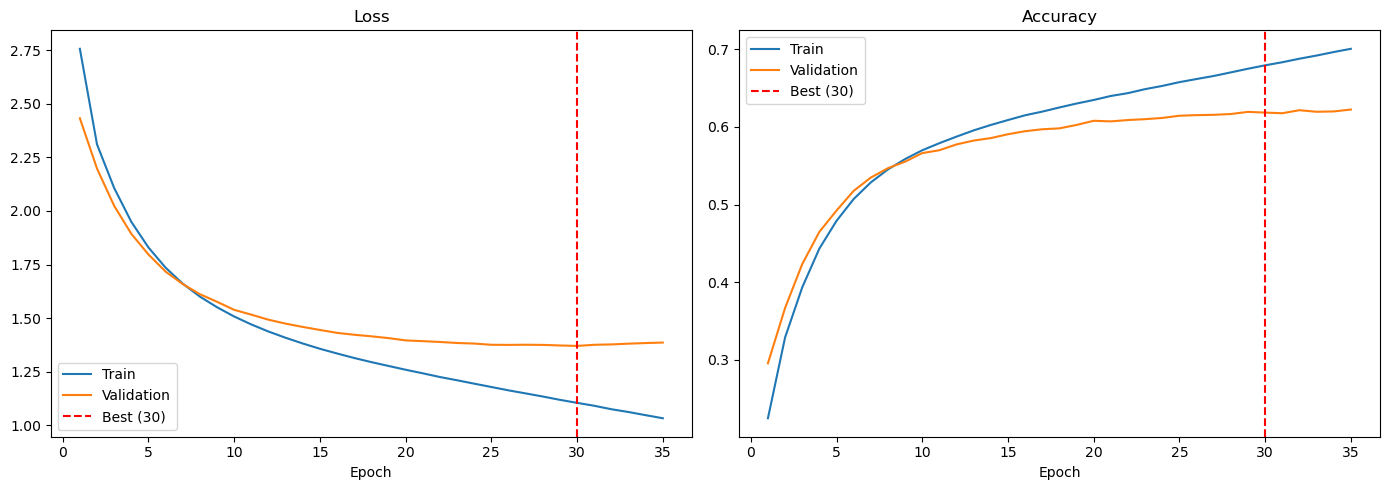

In [5]:
from preprocess import encode_sequences
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

body_encoded = encode_sequences(bodies, char_to_idx, MAX_BODY_LEN, padding='post')
subject_encoded = encode_sequences(subjects, char_to_idx, MAX_SUBJECT_LEN + 2, padding='post')

decoder_input = subject_encoded[:, :-1]
decoder_target = subject_encoded[:, 1:]

print(f"body_encoded:    {body_encoded.shape}")
print(f"decoder_input:   {decoder_input.shape}")
print(f"decoder_target:  {decoder_target.shape}")

MODEL_DIR.mkdir(exist_ok=True)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ModelCheckpoint(str(MODEL_DIR / 'training_model_best.keras'),
                    save_best_only=True, monitor='val_loss', verbose=1)
]

history = training_model.fit(
    [body_encoded, decoder_input],
    decoder_target,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=VALIDATION_SPLIT,
    callbacks=callbacks,
    verbose=1
)

# Chart 01 inline
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
epochs_ran = len(history.history['loss'])
epochs_x = range(1, epochs_ran + 1)
best_epoch = int(np.argmin(history.history['val_loss'])) + 1

ax1.plot(epochs_x, history.history['loss'], label='Train')
ax1.plot(epochs_x, history.history['val_loss'], label='Validation')
ax1.axvline(best_epoch, color='red', linestyle='--', label=f'Best ({best_epoch})')
ax1.set_title('Loss')
ax1.set_xlabel('Epoch')
ax1.legend()

ax2.plot(epochs_x, history.history['accuracy'], label='Train')
ax2.plot(epochs_x, history.history['val_accuracy'], label='Validation')
ax2.axvline(best_epoch, color='red', linestyle='--', label=f'Best ({best_epoch})')
ax2.set_title('Accuracy')
ax2.set_xlabel('Epoch')
ax2.legend()

plt.tight_layout()
plt.show()

## Inference — Why Separate Models?

During training, the decoder receives all input characters at once (teacher forcing). The Keras graph is: `[encoder_inputs, decoder_inputs] → decoder_outputs`.

At inference, we generate one character at a time and feed it back:
1. Run encoder → get `[h, c]`
2. Feed `[START_TOKEN, h, c]` → decoder → get `char_1, [h_1, c_1]`
3. Feed `[char_1, h_1, c_1]` → decoder → get `char_2, [h_2, c_2]`
4. Repeat until `END_TOKEN` or max length

The training model graph can't do this — it expects the full decoder input at once. We build a separate inference decoder that accepts `[single_char, h, c]` and returns `[char_probs, new_h, new_c]`. The weights are the same (shared via the same Keras layer objects); only the graph structure differs.

In [6]:
from model import build_inference_models

inference_encoder, inference_decoder = build_inference_models(
    encoder_inputs, encoder_states,
    decoder_inputs, decoder_embedding, decoder_lstm, decoder_dense,
    vocab_size
)

# Save all models and metadata
training_model.save(str(MODEL_DIR / 'training_model_best.keras'))
inference_encoder.save(str(MODEL_DIR / 'inference_encoder.keras'))
inference_decoder.save(str(MODEL_DIR / 'inference_decoder.keras'))

history_dict = {k: [float(v) for v in vals] for k, vals in history.history.items()}
with open(MODEL_DIR / 'training_history.json', 'w') as f:
    json.dump(history_dict, f)

model_config = {
    'vocab_size': vocab_size,
    'latent_dim': LATENT_DIM,
    'embedding_dim': EMBEDDING_DIM,
    'max_body_len': MAX_BODY_LEN,
    'max_subject_len': MAX_SUBJECT_LEN,
    'epochs_trained': len(history.history['loss']),
    'best_val_loss': float(min(history.history['val_loss'])),
    'best_val_accuracy': float(max(history.history['val_accuracy'])),
    'training_samples': len(bodies),
}
with open(MODEL_DIR / 'model_config.json', 'w') as f:
    json.dump(model_config, f, indent=2)

print("Models and config saved to models/")

# Step-by-step generation for one example
from preprocess import encode_sequences, load_vocab

test_body = bodies[0]
print(f"\nInput body (first 80 chars): {test_body[:80]}...")
print(f"True subject: {subjects[0]}")
print()

body_enc = encode_sequences([test_body], char_to_idx, MAX_BODY_LEN)
states = inference_encoder.predict(body_enc, verbose=0)
h, c = states[0:1], states[1:2]

start_idx = char_to_idx.get(START_TOKEN, 1)
target_seq = np.array([[start_idx]])
generated = []

print("Step-by-step generation (temperature=0.7):")
for step in range(MAX_SUBJECT_LEN):
    out = inference_decoder.predict([target_seq, h, c], verbose=0)
    probs = out[0][0, 0, :]
    h, c = out[1], out[2]

    probs = probs.astype(np.float64)
    probs = np.power(probs, 1.0 / 0.7)
    probs = probs / probs.sum()
    next_idx = np.random.choice(len(probs), p=probs)
    next_char = idx_to_char[next_idx]

    if step < 10:  # print first 10 steps
        top3 = np.argsort(probs)[-3:][::-1]
        top3_chars = [(idx_to_char[i], f"{probs[i]:.3f}") for i in top3]
        print(f"  step {step+1:2d}: top3={top3_chars} → sampled='{next_char}'")

    generated.append(next_char)
    if next_char == END_TOKEN:
        break
    target_seq = np.array([[next_idx]])

result = ''.join(generated).replace(START_TOKEN, '').replace(END_TOKEN, '').strip()
print(f"\nGenerated: '{result}'")

Models and config saved to models/

Input body (first 80 chars): greg/phillip,  attached is the grande communications service agreement.
the busi...
True subject: <service agreement>

Step-by-step generation (temperature=0.7):
  step  1: top3=[('s', '0.341'), ('p', '0.101'), ('c', '0.070')] → sampled='m'


/opt/anaconda3/envs/safety_mark1/lib/python3.12/site-packages/keras/src/models/functional.py:258: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['decoder_inputs', 'decoder_state_h', 'decoder_state_c']
Received: inputs=('Tensor(shape=(1, 1))', ('Tensor(shape=(1, 256))',), ('Tensor(shape=(1, 256))',))
  warnings.warn(msg)


  step  2: top3=[('o', '0.270'), ('e', '0.248'), ('a', '0.219')] → sampled='e'
  step  3: top3=[('e', '0.740'), ('r', '0.144'), ('d', '0.030')] → sampled='e'
  step  4: top3=[('t', '1.000'), ('s', '0.000'), ('c', '0.000')] → sampled='t'
  step  5: top3=[('i', '1.000'), (' ', '0.000'), ('h', '0.000')] → sampled='i'
  step  6: top3=[('n', '1.000'), ('o', '0.000'), ('r', '0.000')] → sampled='n'
  step  7: top3=[('g', '1.000'), ('s', '0.000'), ('i', '0.000')] → sampled='g'
  step  8: top3=[(' ', '0.959'), ('>', '0.035'), (':', '0.003')] → sampled=' '
  step  9: top3=[('w', '0.630'), ('t', '0.153'), ('r', '0.043')] → sampled='r'
  step 10: top3=[('e', '0.989'), ('i', '0.005'), ('u', '0.004')] → sampled='e'

Generated: 'meeting restricted meeting'


In [7]:
# Temperature effect: 0.5 vs 0.7 vs 1.0
from generator import generate_subject

test_bodies = bodies[:3]
temperatures = [0.5, 0.7, 1.0]

print("Temperature comparison:")
print("-" * 80)
for body in test_bodies:
    print(f"Body: {body[:70]}...")
    for t in temperatures:
        gen = generate_subject(body, temperature=t)
        label = 'conservative' if t < 0.6 else ('balanced' if t <= 0.8 else 'creative')
        print(f"  T={t} ({label:12s}): {gen}")
    print()

Temperature comparison:
--------------------------------------------------------------------------------
Body: greg/phillip,  attached is the grande communications service agreement...
  T=0.5 (conservative): socal workshop and other interviews and confidentiality
  T=0.7 (balanced    ): power south services
  T=1.0 (creative    ): fluw isda

Body: phillip & keith  attached is the first draw request, i will need some ...
  T=0.5 (conservative): confirmation on greater
  T=0.7 (balanced    ): complates agreement
  T=1.0 (creative    ): congrats for pgc

Body: your internet banking accounts are now setup again for accessing.
the ...
  T=0.5 (conservative): ata to confirmations
  T=0.7 (balanced    ): contracts cutcomer start to weather first price corp.
  T=1.0 (creative    ): kennedy, direct nominations overay and terminats



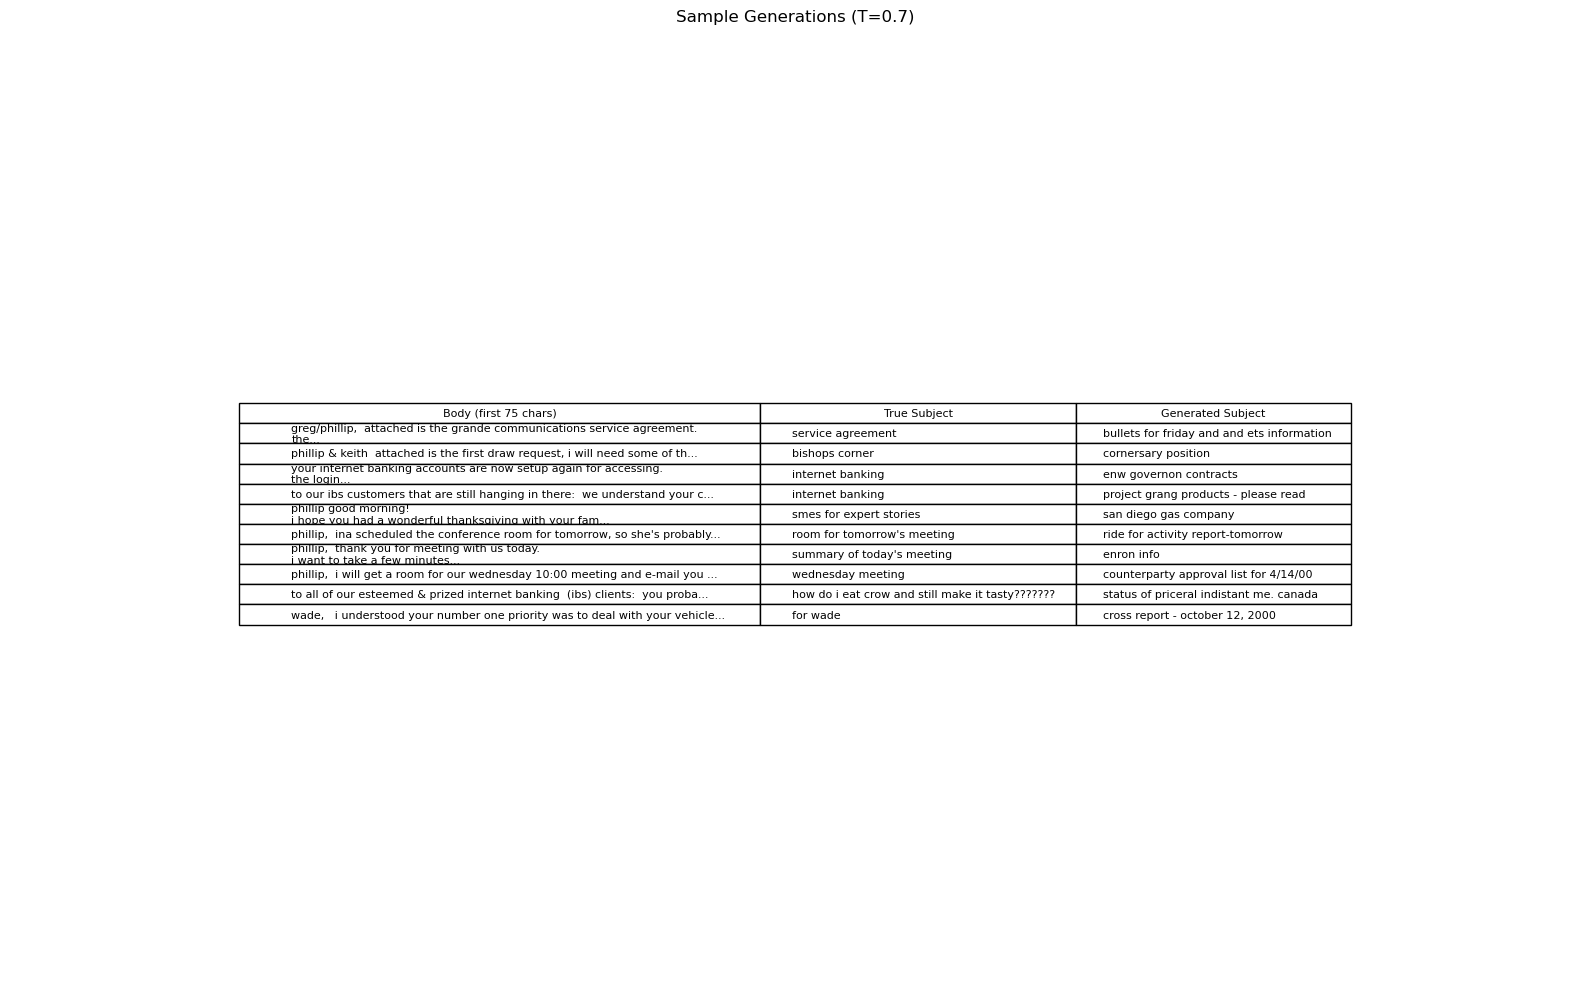

Saved plots/04_sample_generations.png


In [8]:
# Chart 04 — sample generations table inline
from generator import generate_subject

n_samples = 10
sample_bodies = bodies[:n_samples]
sample_subjects = subjects[:n_samples]

generated_subjects = [generate_subject(b) for b in sample_bodies]

fig, ax = plt.subplots(figsize=(16, n_samples * 0.85 + 1.5))
ax.axis('off')

table_data = []
for body, true_sub, gen in zip(sample_bodies, sample_subjects, generated_subjects):
    true_display = true_sub.strip('<>').strip()
    table_data.append([body[:75] + '...', true_display, gen])

table = ax.table(
    cellText=table_data,
    colLabels=['Body (first 75 chars)', 'True Subject', 'Generated Subject'],
    cellLoc='left',
    loc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(8)
table.auto_set_column_width([0, 1, 2])
plt.title('Sample Generations (T=0.7)', fontsize=12, pad=20)
plt.tight_layout()
plt.show()

PLOTS_DIR.mkdir(exist_ok=True)
fig.savefig(PLOTS_DIR / '04_sample_generations.png', dpi=150, bbox_inches='tight')
print("Saved plots/04_sample_generations.png")

## Connecting to the Portfolio

| Project | Architecture | Task type | Output |
|---------|-------------|-----------|--------|
| IMDb sentiment | Discriminative LSTM | Classification | Fixed label (pos/neg) |
| Stock trend | Discriminative LSTM | Classification | Fixed label (up/down) |
| **Email subject** | **Generative LSTM (encoder-decoder)** | **Conditional generation** | **Novel text sequence** |

The IMDb and stock projects show that LSTMs can learn from sequential patterns to classify. This project shows that the same LSTM building block, arranged in an encoder-decoder structure, can *generate* novel sequences conditioned on input. The architecture gap: discriminative → generative.

## Azure App Service Deployment

```bash
# 1. Create infrastructure (F1 free tier — do this once)
az group create --name email-subject-gen-rg --location westeurope
az appservice plan create --name email-subject-gen-plan \
  --resource-group email-subject-gen-rg --sku F1 --is-linux
az webapp create --name email-subject-gen-xoc \
  --resource-group email-subject-gen-rg \
  --plan email-subject-gen-plan --runtime "PYTHON:3.11"
az webapp config set --name email-subject-gen-xoc \
  --resource-group email-subject-gen-rg \
  --startup-file "gunicorn main:app --workers 1 --worker-class uvicorn.workers.UvicornWorker --bind 0.0.0.0:8000 --timeout 600"
az webapp config appsettings set --name email-subject-gen-xoc \
  --resource-group email-subject-gen-rg \
  --settings SCM_DO_BUILD_DURING_DEPLOYMENT=true

# 2. Manual deploy (zip only app files — not notebooks, data, plots)
zip -rq deploy.zip main.py generator.py config.py preprocess.py \
  requirements.txt startup.txt models/ templates/
TOKEN=$(az account get-access-token --query accessToken -o tsv)
curl -X POST \
  "https://email-subject-gen-xoc.scm.azurewebsites.net/api/zipdeploy" \
  -H "Authorization: Bearer $TOKEN" \
  -H "Content-Type: application/zip" \
  --data-binary @deploy.zip

# 3. Set up CI/CD secret (run once after step 1)
az ad sp create-for-rbac \
  --name "email-subject-gen-gh-actions" \
  --role contributor \
  --scopes /subscriptions/<sub-id>/resourceGroups/email-subject-gen-rg \
  --sdk-auth | gh secret set AZURE_CREDENTIALS \
  --repo xavier-oc-programming/email-subject-generator
```

After step 3, every push to `main` deploys automatically via GitHub Actions CI.

## Key Findings

_Fill after running training:_
- **Best val_loss:** TBD
- **Best val_accuracy:** TBD
- **Epochs to convergence:** TBD
- **Observations on generation quality:** TBD
- **Temperature sensitivity:** TBD